# El Niño Forecasting — Classical Machine Learning
---
Three regression models are compared across multiple forecast lead times:

| Model | Notes |
|-------|-------|
| **Linear Regression** | OLS baseline |
| **Ridge Regression** | L2-regularised; α selected by leave-one-out CV |
| **Random Forest** | Ensemble of 300 trees |

**Targets per lead time**
- **PC1** and **PC2** – first two SST principal components (direct regression)
- **EN 3.4** – El Niño 3.4 index, derived as a linear combination of the predicted PC1 and PC2

**Feature engineering**  
Each model receives `n_lags` lagged values of the target PC as predictors
(optionally augmented with cyclic month encodings).


## 1 · Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score

from preprocess import preprocess


## 2 · Data loading

In [2]:
# `data` is a DataFrame with columns: PC1, PC2, EN_34 (monthly index)
# The SST DataArrays (sst_tropical, sst_anom) are not needed for ML models.
data, _, __ = preprocess()


## 3 · Supervised dataset builder

`create_supervised_dataset` converts the raw PC time series into a tabular
supervised-learning format suitable for any sklearn regressor.

**Features:** – `n_lags + 1` lagged values of the target PC  
 (lag-0 = current value, lag-1 = one month ago, …, lag-n_lags = n months ago),
 plus optional cyclic month encodings (sin/cos) to capture seasonality.

**Target:** – the absolute PC value `lead_time` months ahead.


In [3]:
def create_supervised_dataset(
    df,
    target_col: str,
    lead_time: int = 1,
    n_lags: int = 6,
    include_month: bool = False,
):
    """
    Build features (X), PC target (y), and the corresponding EN 3.4 series.

    Parameters
    ----------
    df           : pd.DataFrame  with at least columns [target_col, 'EN_34']
    target_col   : 'PC1' or 'PC2' – the PC to forecast
    lead_time    : forecast horizon in months
    n_lags       : number of lagged values to include as features
                   (lags 0 … n_lags, inclusive)
    include_month: if True, add sin/cos month encodings to capture seasonality

    Returns
    -------
    X            : pd.DataFrame  – feature matrix
    y            : pd.Series     – target PC values (absolute)
    en34_series  : pd.Series     – true EN 3.4 at the same future time steps
    """
    X = pd.DataFrame(index=df.index)

    # Lagged features: lag-0 is the current value, lag-k is k months ago
    for lag in range(n_lags + 1):
        X[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    # Optional cyclic month encoding to help models learn seasonal patterns
    if include_month:
        months = df.index.month
        X["sin_month"] = np.sin(2 * np.pi * months / 12)
        X["cos_month"] = np.cos(2 * np.pi * months / 12)

    # Absolute target: the PC value lead_time months into the future
    y = df[target_col].shift(-lead_time)

    # True EN 3.4 at the same future time step (used for evaluation only)
    en34_future = df["EN_34"].shift(-lead_time)

    # Align everything and drop rows with NaN (boundaries of lags / lead)
    combined = pd.concat(
        [X, y.rename("target"), en34_future.rename("en34")],
        axis=1,
    ).dropna()

    return combined.drop(columns=["target", "en34"]), combined["target"], combined["en34"]


## 4 · Evaluation & plotting

`plot_test` trains a fresh model for every lead time, collects predictions for
PC1 and PC2, derives the EN 3.4 forecast via a linear combination, and produces
a figure with three columns (PC1 | PC2 | EN 3.4) and one row per lead time.

The EN 3.4 linear combiner is fit **once** on the training portion of the data
so it never sees test-set labels.


In [4]:
def plot_test(
    model,
    data,
    leads_to_plot,
    n_lags: int = 12,
    split: float = 0.8,
    regressor_kwargs: dict = None,
    model_name: str = None,
):
    """
    Train `model` for each lead time and plot PC1, PC2, and EN 3.4 forecasts.

    Parameters
    ----------
    model            : sklearn regressor class (not an instance)
    data             : pd.DataFrame  with columns PC1, PC2, EN_34
    leads_to_plot    : iterable of int – forecast horizons in months
    n_lags           : number of lagged features (passed to create_supervised_dataset)
    split            : train / test chronological split fraction
    regressor_kwargs : keyword arguments forwarded to the model constructor
    model_name       : label shown in the legend (defaults to model.__name__)
    """
    if regressor_kwargs is None:
        regressor_kwargs = {}
    if model_name is None:
        model_name = model.__name__

    #  Figure layout 
    fig, axes = plt.subplots(
        nrows=len(leads_to_plot),
        ncols=3,
        figsize=(20, 3 * len(leads_to_plot)),
        sharex=True,
        constrained_layout=True,
    )
    # Ensure axes is always 2-D (rows × cols) even for a single lead time
    if len(leads_to_plot) == 1:
        axes = np.expand_dims(axes, axis=0)

    #  EN 3.4 linear combiner 
    # Fit once on the training slice so the combiner never sees test labels.
    train_end = int(len(data) * split)
    lr_en34 = LinearRegression().fit(
        data[["PC1", "PC2"]].iloc[:train_end].values,
        data["EN_34"].iloc[:train_end].values,
    )

    #  Loop over lead times 
    for row_idx, lead in enumerate(leads_to_plot):
        ax_pc1, ax_pc2, ax_en34 = axes[row_idx]

        preds_abs = {}   # {target: np.ndarray of test-set predictions}

        #  PC1 and PC2 forecasts 
        for target, ax in [("PC1", ax_pc1), ("PC2", ax_pc2)]:
            X, y, en34_true = create_supervised_dataset(
                data, target, lead_time=lead, n_lags=n_lags
            )

            # Chronological train / test split
            split_idx = int(len(X) * split)
            X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
            y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

            # Fit and predict
            reg = model(**regressor_kwargs)
            reg.fit(X_train, y_train)
            y_pred = reg.predict(X_test)
            y_true = y_test.values

            preds_abs[target] = y_pred

            # Metrics
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            r2   = r2_score(y_true, y_pred)
            corr = np.corrcoef(y_true, y_pred)[0, 1] if len(y_true) > 1 else np.nan

            # Time axis: shift by lead months so it represents the prediction target date
            t_axis = y_test.index + pd.DateOffset(months=lead)

            ax.plot(t_axis, y_true, color="black", alpha=0.85, label="Actual")
            ax.plot(t_axis, y_pred, color="green", linestyle="--", label=model_name)
            ax.axhline(0, color="gray", linewidth=0.8)
            ax.grid(True, alpha=0.3, linestyle=":")
            ax.set_title(f"{target} | lead={lead} | R²={r2:.2f}  RMSE={rmse:.2f}  Corr={corr:.2f}")
            if row_idx == 0:
                ax.legend(loc="upper left", frameon=True)

        #  EN 3.4 forecast (linear combination of predicted PC1 & PC2) 
        # Reuse the split index and time axis from the last PC loop iteration
        en34_test_true = en34_true.iloc[split_idx:]
        en34_pred = lr_en34.predict(
            np.column_stack([preds_abs["PC1"], preds_abs["PC2"]])
        )

        rmse = np.sqrt(mean_squared_error(en34_test_true, en34_pred))
        r2   = r2_score(en34_test_true, en34_pred)
        corr = (
            np.corrcoef(en34_test_true, en34_pred)[0, 1]
            if len(en34_test_true) > 1
            else np.nan
        )

        ax_en34.plot(t_axis, en34_test_true, color="black", alpha=0.85, label="Actual")
        ax_en34.plot(t_axis, en34_pred, color="red", label="EN_34  Linear Reg on PC1 and PC2")
        ax_en34.axhline(0, color="gray", linewidth=0.8)
        ax_en34.grid(True, alpha=0.3, linestyle=":")
        ax_en34.set_title(f"EN_34 | lead={lead} | R²={r2:.2f}  RMSE={rmse:.2f}  Corr={corr:.2f}")
        if row_idx == 0:
            ax_en34.legend(loc="upper left", frameon=True)

    fig.suptitle("Forecasts: PC1 | PC2 | El Niño 3.4", fontsize=16, y=1.02)
    plt.show()


## 5 · Shared settings

In [5]:
LEADS_TO_PLOT = [1, 3, 6, 9, 12, 18, 24]  # forecast horizons (months)
WINDOW        = 12                          # number of lag features


## 6 · Linear Regression

OLS baseline — no regularisation, no hyper-parameters.
Useful for gauging how much a model needs to add beyond a simple linear relationship.


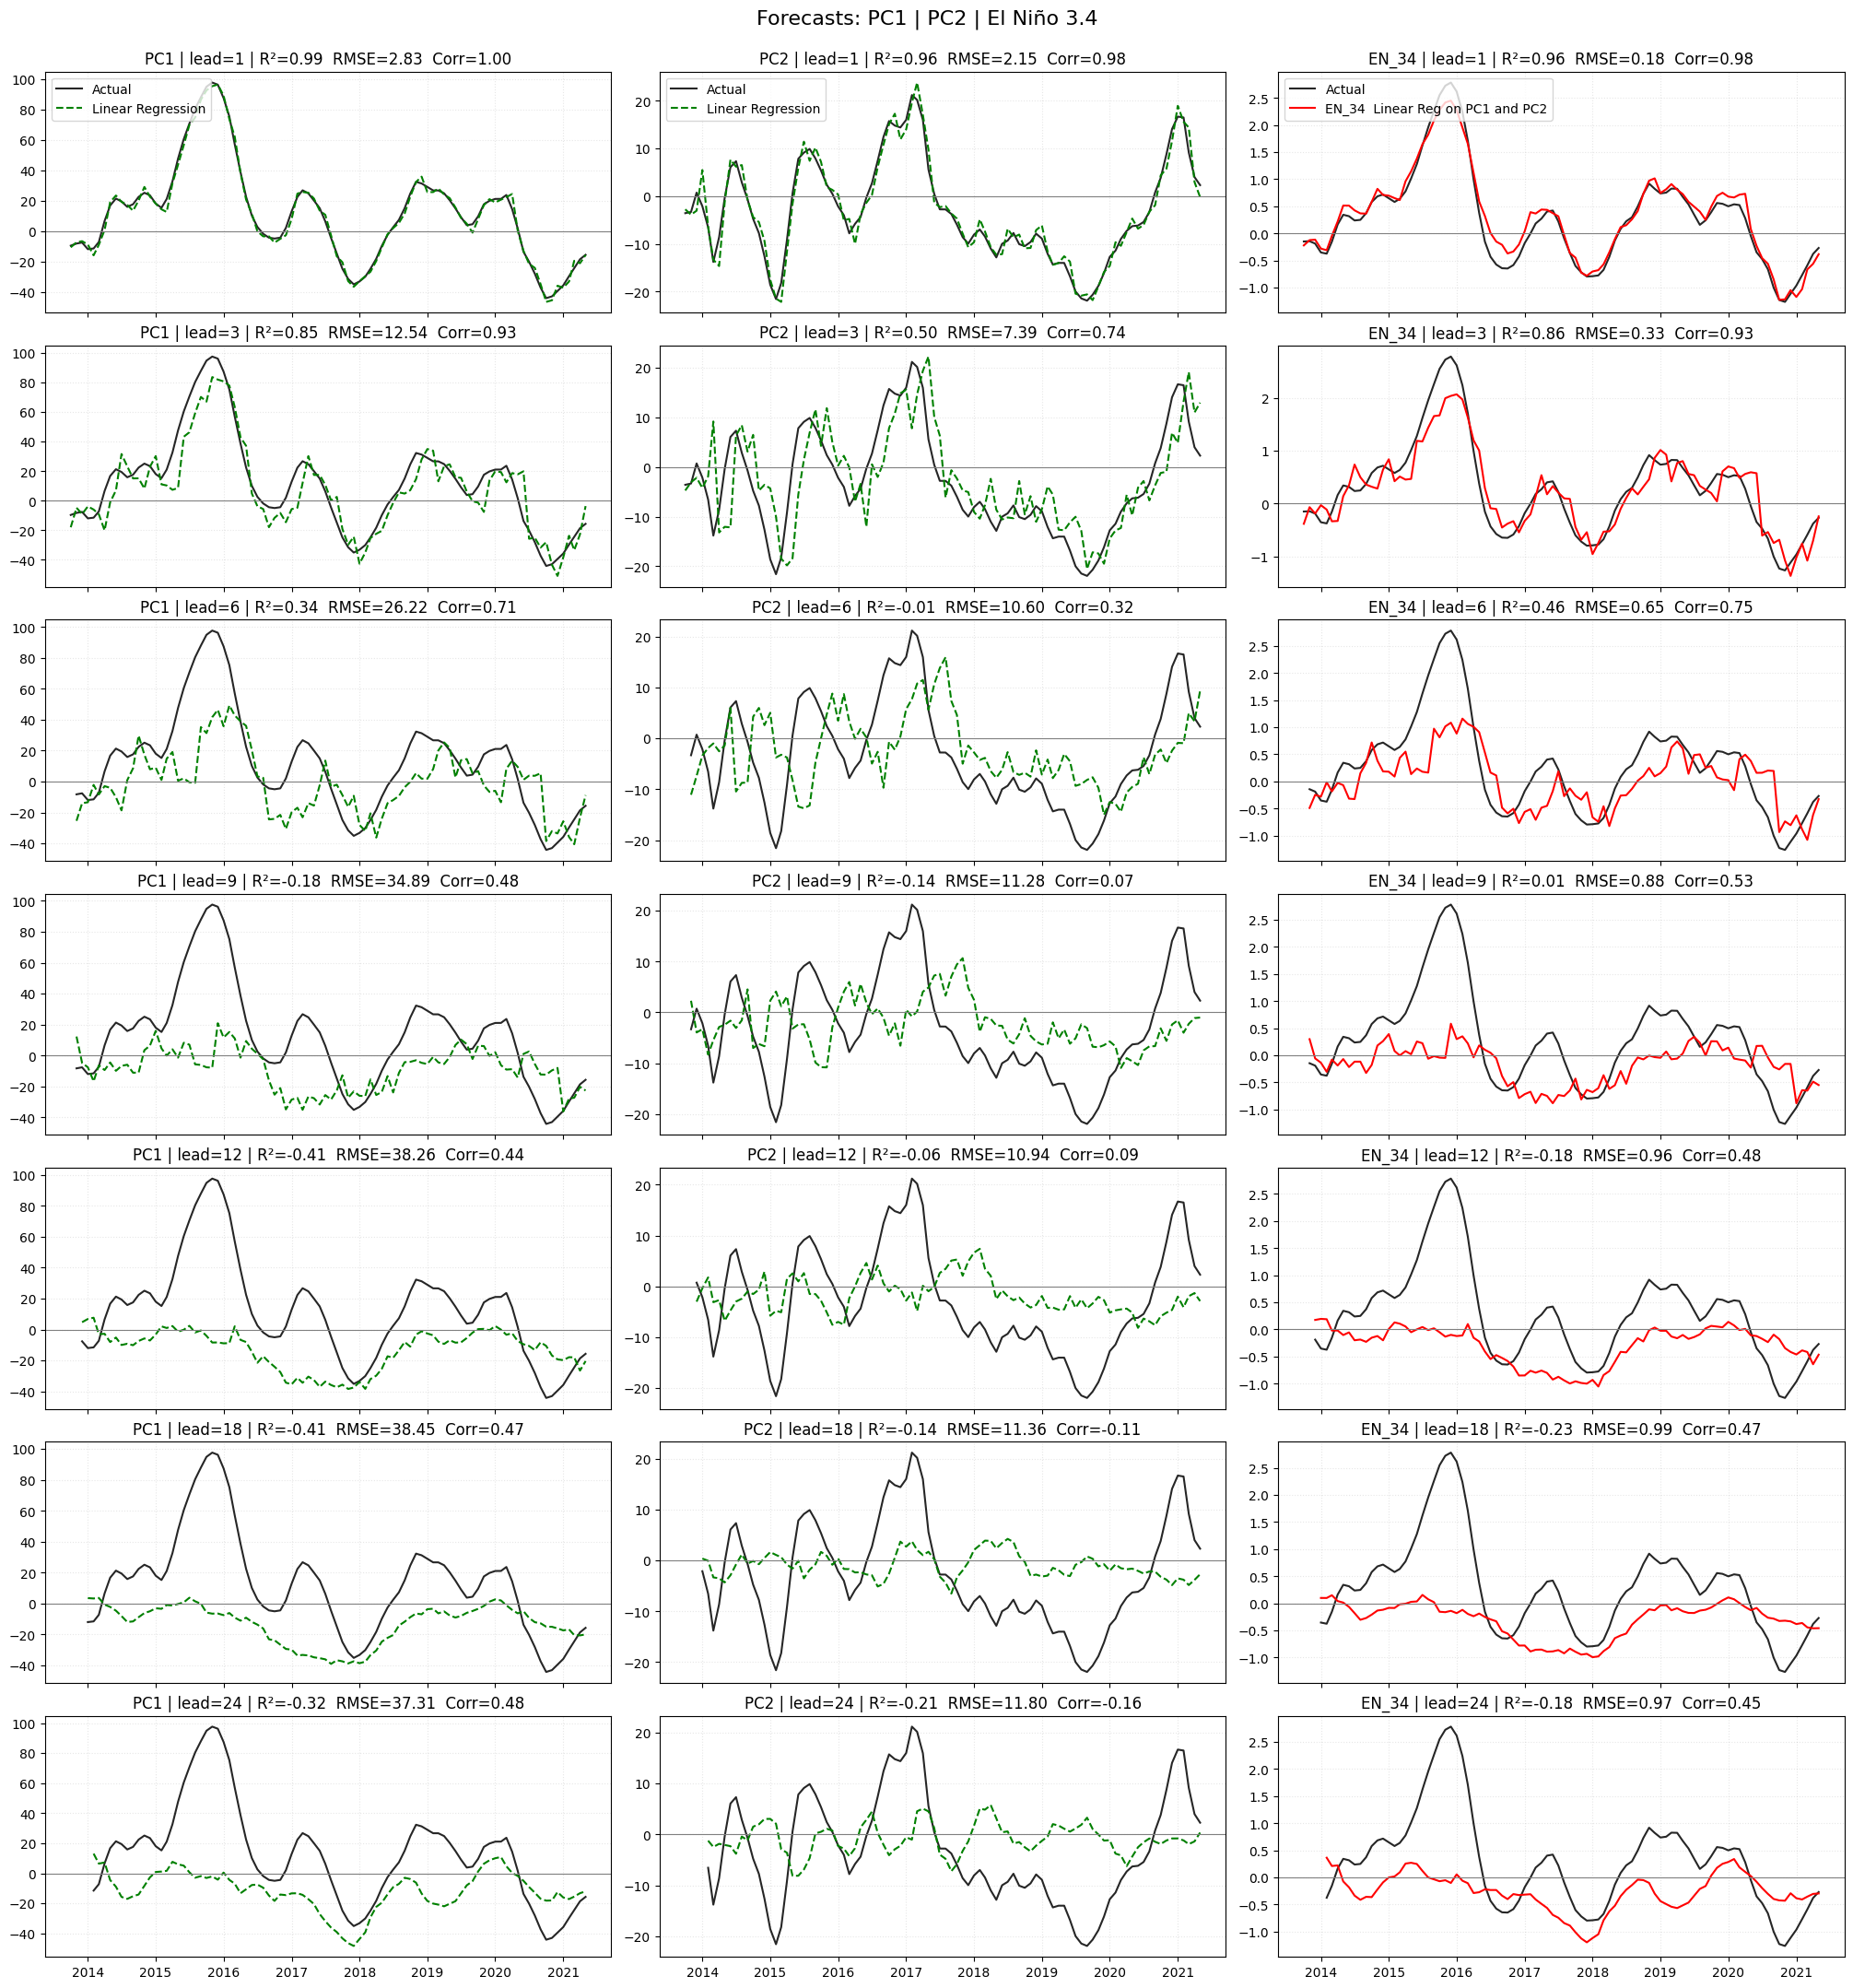

In [6]:
plot_test(
    LinearRegression,
    data=data,
    leads_to_plot=LEADS_TO_PLOT,
    n_lags=WINDOW,
    model_name="Linear Regression",
)


## 7 · Ridge Regression

L2-regularised linear model.  
`RidgeCV` selects the regularisation strength α via leave-one-out cross-validation
over a logarithmic grid from 10⁻⁵ to 10⁵ (50 candidates).  
Ridge is especially useful at long lead times where the signal is weak and OLS overfits.


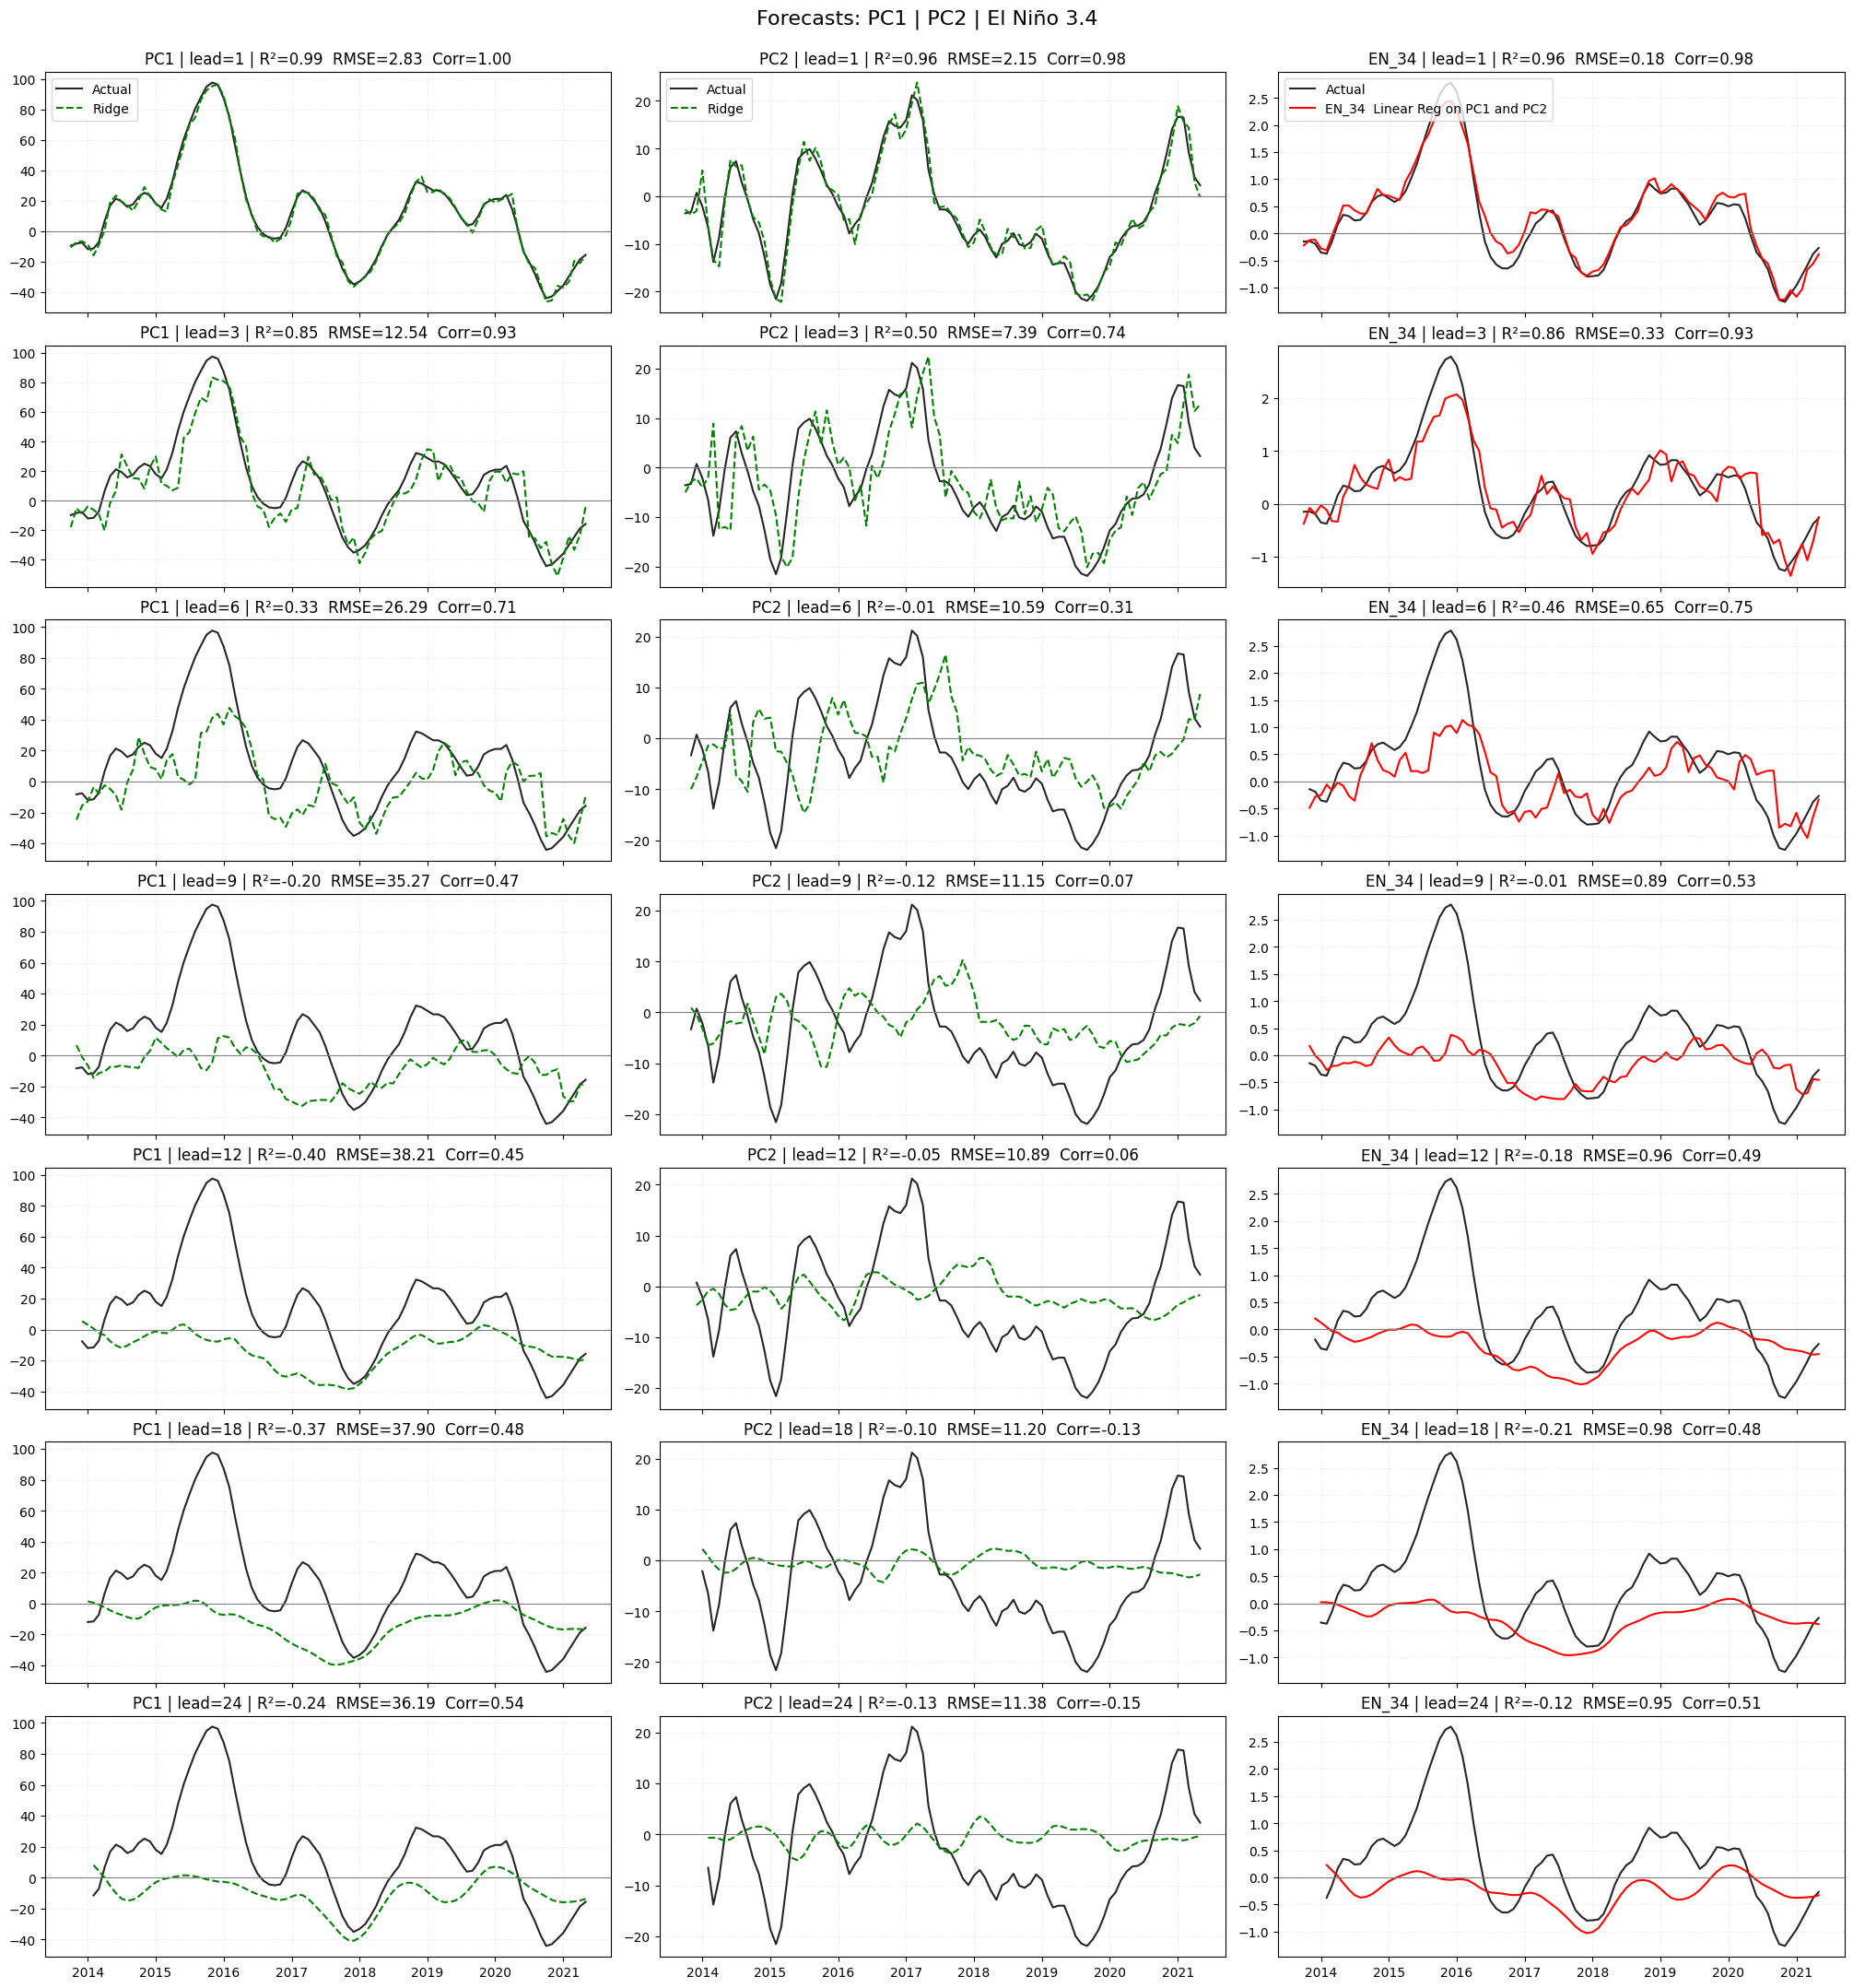

In [7]:
plot_test(
    RidgeCV,
    data=data,
    leads_to_plot=LEADS_TO_PLOT,
    n_lags=WINDOW,
    regressor_kwargs={"alphas": np.logspace(-5, 5, 50)},
    model_name="Ridge",
)


## 8 · Random Forest

Ensemble of 300 decorrelated decision trees.  
Key hyper-parameters:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 300 | More trees → lower variance; diminishing returns beyond ~200 |
| `max_depth` | None | Trees grow fully; controlled by `min_samples_leaf` |
| `min_samples_leaf` | 2 | Light pruning to avoid fitting individual outliers |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Use all available CPU cores |


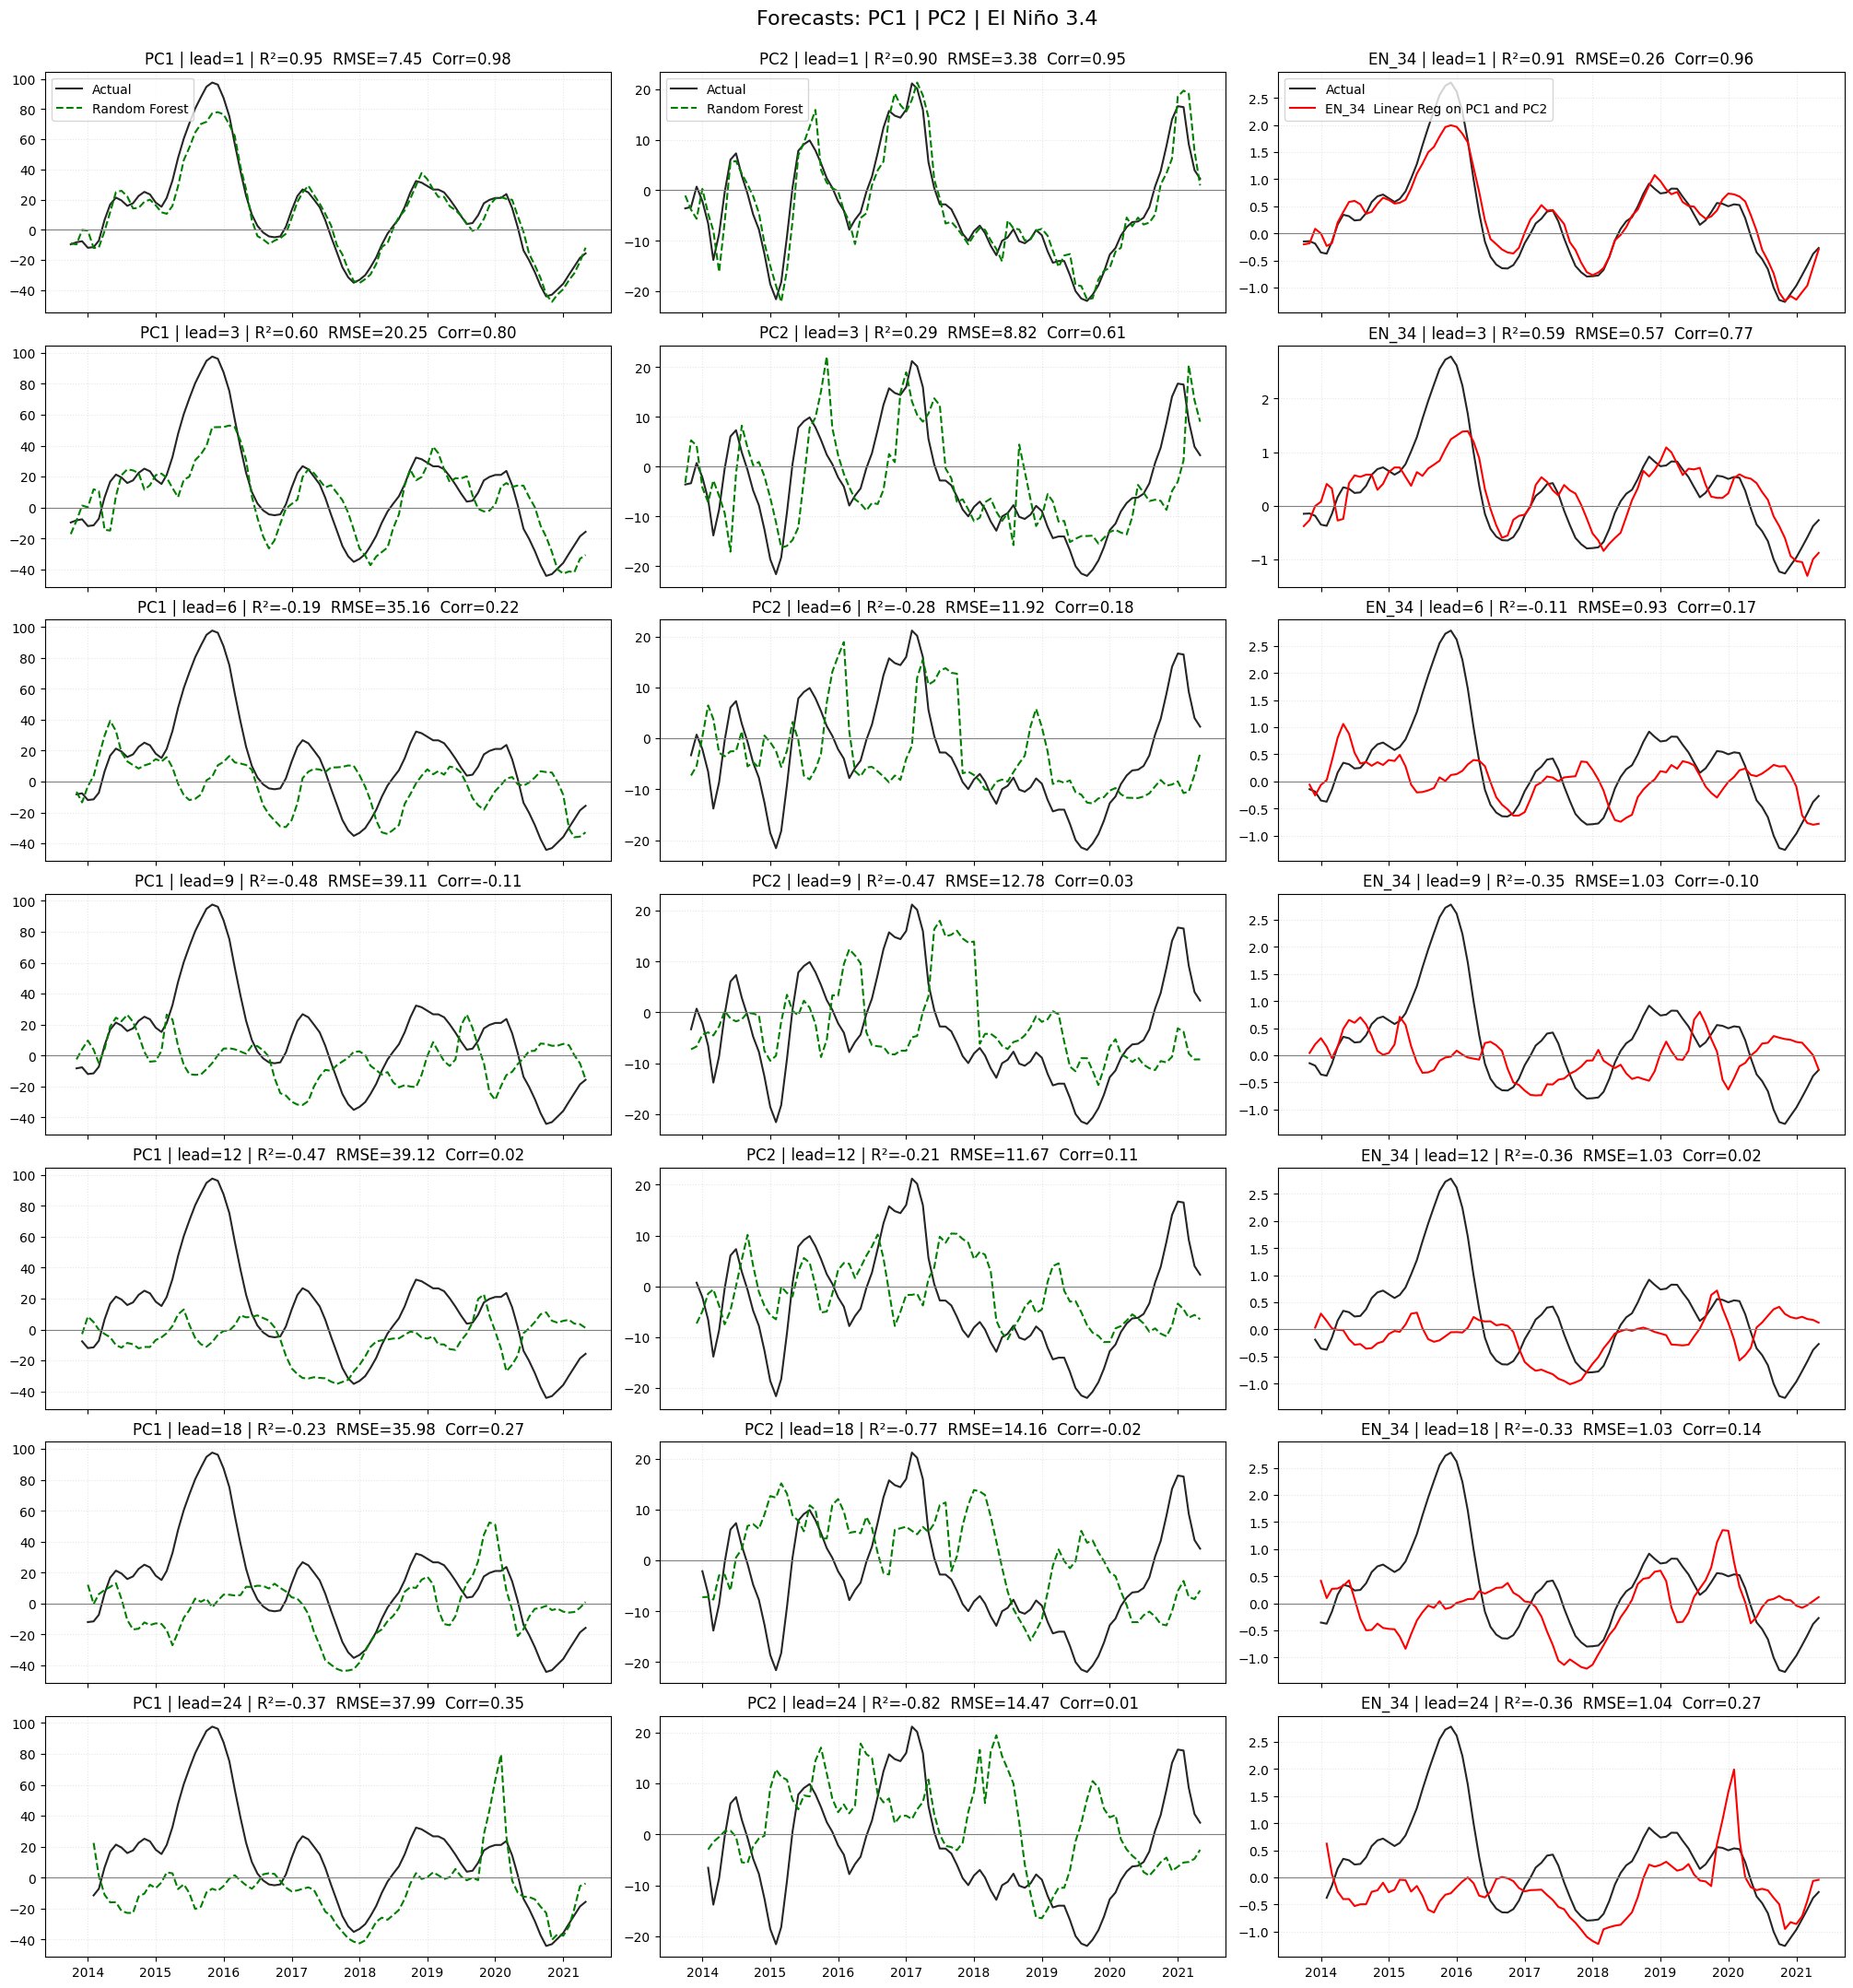

In [8]:
plot_test(
    RandomForestRegressor,
    data=data,
    leads_to_plot=LEADS_TO_PLOT,
    n_lags=WINDOW,
    regressor_kwargs={
        "n_estimators"   : 300,
        "max_depth"      : None,
        "min_samples_leaf": 2,
        "random_state"   : 42,
        "n_jobs"         : -1,
    },
    model_name="Random Forest",
)
